# 02 — Consistency & Reliability

**Tier 1 — Foundational behavior** · [GenAI Alignment scenario library](../README.md#scenario-library) · reused adapter (chatbot) + new adapter (agentic)

> **In one sentence:** if you ask the same question — or give the same task — twice, do you get essentially the same answer, or does it depend on the run?

Scenario 1 ([Intended Performance](../docs/intended_performance.md)) already surfaced this by accident: re-running its exact golden set against the same model gave different pass rates on separate occasions. This scenario makes that observation the actual test, across **two different kinds of system**, because "consistent" means something different for each:

| | |
|---|---|
| **Risk if untested** | Same input yields different output; hallucination / variance. |
| **What "consistent" means here** | Not exact-match — a chatbot's answer can be worded differently and still be the same answer; an agent can call a differently-named-but-equivalent tool and still take the same action. Consistency is checked at the level that actually matters for each system type, not at the text level by default. |

Two tracks:

1. **Chatbot track** — scenario 1's exact two golden sets, each run 5× through the identical adapter. Consistency = pass/fail doesn't flip across runs, *and* the raw answers agree with each other (not just with the reference).
2. **Agentic track** — a fixed Mind2Web task subset, run 5× through [`multi_agent_otel_eval`](https://github.com/minw0607/multi_agent_otel_eval), in both single-agent and multi-agent mode. Consistency here isn't text comparison — it's whether the task outcome and the *tools chosen* stay stable run to run, using that framework's own equivalence-aware tool scoring.

This notebook is code-light — everything above lives in [`scenarios/consistency_reliability.py`](../scenarios/consistency_reliability.py) and the generic repeat-run mechanics (usable by any future scenario that needs "run N times and compare," including drift detection) live in [`reporting/repeat_run.py`](../reporting/repeat_run.py).

Statistical methodology is drawn from the published literature, not invented in-house — see [Methodology](#methodology-refinements) right after Setup for what's used and why, with references.

**How to read this notebook:** run every cell top to bottom once — the agentic track (`harness`, `agentic_runs`, `agentic_var`) depends on cells that come before it, and takes noticeably longer than the chatbot track (see the time estimate in each section). If you only want the end result, jump to the [Testing Report](#reporting-template) near the bottom; everything above it is how those numbers were produced. See [How to Extend This Scenario](#how-to-extend) if you want to change *what's* tested rather than just re-run it.

## ⚙️ Setup

The agentic track needs [`multi_agent_otel_eval`](https://github.com/minw0607/multi_agent_otel_eval) cloned as a sibling of this repo's parent directory (it has no `pyproject.toml`, so it isn't pip-installable like the other sibling repos this project depends on), plus its own runtime dependencies:

```bash
cd .. && git clone https://github.com/minw0607/multi_agent_otel_eval Agent
cd genai_alignment && pip install -e ".[agentic]"
```

See [README — Setup](../README.md#setup) for the general dependency setup if this is your first notebook here. The cell below checks all of this and tells you exactly what's missing, rather than letting a cell fail 10 minutes into the agentic track.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
load_dotenv(Path.cwd() / ".env")

from scenarios import consistency_reliability as scenario
from reporting.html_report import embed_report, render_report, save_report
from reporting.env_check import check_environment
from reporting.artifacts import artifact_trail

pd.set_option("display.max_colwidth", 120)
target_model = os.environ.get("TARGET_MODEL", "<unset>")
api_version = os.environ.get("OPENAI_API_VERSION", "<unset>")


### Environment Check

In [2]:
ready = check_environment(
    required_packages=["genai_capability_bench", "jinja2", "matplotlib", "sklearn"],
    required_env_vars=["OPENAI_API_KEY", "OPENAI_BASE_URL", "OPENAI_API_VERSION", "TARGET_MODEL"],
    sibling_repos={"../Agent": "https://github.com/minw0607/multi_agent_otel_eval"},
)
assert ready, "Fix the items above before continuing — the agentic track alone takes ~15-20 minutes and real API spend."


✓ package: genai_capability_bench  OK
✓ package: jinja2                  OK
✓ package: matplotlib              OK
✓ package: sklearn                 OK
✓ env var: OPENAI_API_KEY          OK
✓ env var: OPENAI_BASE_URL         OK
✓ env var: OPENAI_API_VERSION      OK
✓ env var: TARGET_MODEL            OK
✓ sibling repo: ../Agent           OK

All checks passed.


<a id="methodology-refinements"></a>
## 📐 Methodology — Statistical Refinements

Three methods, each drawn from published work rather than an in-house choice — see [`reporting/repeat_run.py`](../reporting/repeat_run.py) for the implementation and [`docs/consistency_reliability.md`](../docs/consistency_reliability.md) for the full write-up.

| Signal | Method | Why |
|---|---|---|
| Text self-consistency | **Semantic consistency** — cluster the N answers by bidirectional entailment, score `1 − normalized entropy` over cluster sizes | Bidirectional entailment (does A imply B *and* B imply A?) is the actual test for "these mean the same thing" — not a lexical-overlap proxy for it. |
| Pass-rate confidence | **Wilson score interval** | Well-calibrated at small n (n=5 here), unlike a normal-approximation standard error, which can even fall outside [0, 1]. |
| Which tasks are unreliable | **Benjamini-Hochberg-corrected significance test** against a stated 80% reliability floor | Controls the false-discovery rate across all 40 tasks tested simultaneously, rather than reading each task's raw `flips` flag in isolation. |

**One more layer on top of the significance test, and the reason it exists:** `significant_below_floor` alone conflates two structurally different findings — a task that genuinely flips run to run, and a task that fails (or passes) *every single run identically*, which isn't instability at all. `reliability_category` splits this into `unstable` (significant and flips — a real consistency finding), `consistently_failing` (significant, never flips — a capability gap or scoring-threshold artifact riding along on the same test), and `reliable`. Read `reliability_category` first; `flips` and `significant_below_floor` are still there individually if you want the raw signals it's built from.

**Cost note:** semantic consistency adds LLM entailment calls for the chatbot track — but only for tasks whose 5 answers aren't already identical strings (an exact-match short-circuit skips the LLM call entirely), so the actual added cost depends on how much real textual variation shows up this run, not a fixed number. For dev iteration or a cost-constrained run, `scenario.chatbot_variance(..., use_semantic_entropy=False)` swaps in the free TF-IDF check instead — same output columns, no client required, less accurate on paraphrased answers.

**References:**
- Kuhn, L., Gal, Y., & Farquhar, S. (2024). [Detecting hallucinations in large language models using semantic entropy](https://www.nature.com/articles/s41586-024-07421-0). *Nature*.
- Wilson, E. B. (1927). Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association*.
- Benjamini, Y., & Hochberg, Y. (1995). Controlling the false discovery rate: a practical and powerful approach to multiple testing. *Journal of the Royal Statistical Society: Series B*.
- Manakul, P., Liusie, A., & Gales, M. (2023). [SelfCheckGPT: Zero-Resource Black-Box Hallucination Detection for Generative Large Language Models](https://arxiv.org/abs/2303.08896) — the "sample N times and check mutual support" pattern this whole scenario is built on.
- Wang, X., et al. (2022). [Self-Consistency Improves Chain of Thought Reasoning in Language Models](https://arxiv.org/abs/2203.11171) — origin of the "self-consistency" term (an inference-time technique, distinct from what's measured here).
- [`alepot55/agentrial`](https://github.com/alepot55/agentrial) — an open-source framework built around the same "run an agent N times, compute confidence intervals, correct for multiple comparisons" premise as this scenario's agentic track; evaluated as a possible replacement, but its statistical methods (Wilson CIs, BH correction) are now implemented natively here instead, so adopting it wholesale would be redundant rather than additive.

## 💬 Chatbot Track

Reuses scenario 1's two golden sets and adapter completely unchanged — this track only adds the *repeat* dimension. Each of the 40 tasks (10 custom + 30 public benchmark) runs 5 times through the identical config.

**Methodology — what "consistent" means here, precisely:** three signals, none of which is exact-match, plus a corrected significance test:
1. **Pass/fail flip rate** — does a task cross the 0.70 threshold in some runs and not others? This inherits scenario 1's scoring (lexical/semantic match against a reference), so it's already tolerant of paraphrasing at the pass/fail level. Raw and descriptive — see #3.
2. **Semantic consistency** — do the 5 raw answers cluster into one meaning or several, via bidirectional-entailment clustering (see [Methodology](#methodology-refinements) above), not against the reference. This exists because pass/fail alone can hide instability: a task can pass every run while meaning something different each time, which flip-rate wouldn't catch on its own.
3. **BH-corrected reliability significance** — is this task's pass rate statistically distinguishable from an 80% reliability floor, after correcting for testing all 40 tasks at once? This is the rigorous version of #1; a raw flip isn't automatically a significant finding.

**What this section spends:** 200 API calls to generate the answers (40 tasks × 5 repeats), plus a variable number of entailment-check calls for semantic consistency (only spent where real textual variation exists) — roughly 6–10 minutes total.

In [3]:
display(Markdown(f"**Target:** Azure OpenAI · `{target_model}` · API version `{api_version}`"))
chatbot_runs = scenario.run_chatbot_repeats(n=scenario.CHATBOT_N_REPEATS)
print(f"{len(chatbot_runs['results'])} rows collected ({scenario.CHATBOT_N_REPEATS} repeats × 40 tasks)")


**Target:** Azure OpenAI · `gpt-5-5-20260424-gs` · API version `2025-04-01-preview`

Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10     0.9501        0.9          1440.0


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10      0.863        0.7          1210.3


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10     0.8477        0.7          1371.3


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10     0.8748        0.7          1362.3


...

Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9737        1.0          1487.8
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1986.8
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2085.2
azure-target answer_accuracy                history  2     1.0000        1.0          2204.7
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          2196.6
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3158.8
azure-target answer_accuracy                science 10     0.8000        0.8          1687.5


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9737        1.0          1409.7
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1748.3
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2027.4
azure-target answer_accuracy                history  2     1.0000        1.0          2108.3
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1976.2
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3216.8
azure-target answer_accuracy                science 10     0.7000        0.7          2251.9


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9682        0.9          7310.0
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1626.0
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          1823.5
azure-target answer_accuracy                history  2     1.0000        1.0          2195.0
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          2037.5
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3783.7
azure-target answer_accuracy                science 10     0.7000        0.7          2387.5


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9737        1.0          1633.7
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1507.0
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2616.9
azure-target answer_accuracy                history  2     1.0000        1.0          1513.8
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1872.0
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3678.4
azure-target answer_accuracy                science 10     0.7000        0.7          2267.5


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9737        1.0          1374.4
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1434.1
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          3678.5
azure-target answer_accuracy                history  2     1.0000        1.0          1922.3
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1807.9
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3383.2
azure-target answer_accuracy                science 10     0.7000        0.7          2524.3
200 rows collected (5 repeats × 40 tasks)


In [4]:
consistency_client = scenario.build_judge_client(target_model)
chatbot_var = scenario.chatbot_variance(chatbot_runs["results"], consistency_client)
chatbot_var.sort_values("score_std", ascending=False).head(10)


,task_id,n_runs,avg_score,score_std,pass_rate,flips,dataset_label,category,semantic_consistency,n_meaning_clusters,pass_rate_ci_low,pass_rate_ci_high,reliability_p_value,significant_below_floor,reliability_category
6,answer_accuracy_knowledge_v1_Mercury_SC_401375,5,0.400000,0.547723,0.4,True,public_benchmark_sample,science,0.581834,2,0.117618,0.769280,0.05792,False,reliable
5,answer_accuracy_knowledge_v1_Mercury_SC_400063,5,0.800000,0.447214,0.8,True,public_benchmark_sample,science,0.689082,2,0.375528,0.963777,0.67232,False,reliable
34,ip-05,5,0.789113,0.288769,0.6,True,custom_golden_set,hr_it_policy,0.581834,2,0.230720,0.882382,0.26272,False,reliable
39,ip-10,5,0.731384,0.168339,0.8,True,custom_golden_set,hr_it_policy,0.689082,2,0.375528,0.963777,0.67232,False,reliable
31,ip-02,5,0.708993,0.162678,0.2,True,custom_golden_set,hr_it_policy,0.689082,2,0.036223,0.624472,0.00672,False,reliable
36,ip-07,5,0.930100,0.156301,0.8,True,custom_golden_set,hr_it_policy,1.000000,1,0.375528,0.963777,0.67232,False,reliable
33,ip-04,5,0.964425,0.055126,1.0,False,custom_golden_set,hr_it_policy,0.581834,2,0.565509,1.000000,1.00000,False,reliable
38,ip-09,5,0.981302,0.041809,1.0,False,custom_golden_set,hr_it_policy,1.000000,1,0.565509,1.000000,1.00000,False,reliable
37,ip-08,5,0.697071,0.037967,0.2,True,custom_golden_set,hr_it_policy,1.000000,1,0.036223,0.624472,0.00672,False,reliable
11,answer_accuracy_knowledge_v1_bt_3054,5,0.725849,0.024415,0.8,True,public_benchmark_sample,general_knowledge,0.689082,2,0.375528,0.963777,0.67232,False,reliable


**How to read the table above:**
- `reliability_category` is the main column to read first — it splits `significant_below_floor` into what it's actually conflating: `unstable` (significant *and* flipped — genuine run-to-run variance, what this scenario tests for), `consistently_failing` (significant but never flipped — the same result every run, a capability gap or scoring artifact, not instability), or `reliable`.
- `flips=True` alone is a raw, descriptive signal (did the outcome ever disagree) — `reliability_category` is the statistically-grounded version of the same question, and the two won't always point the same way.
- On a `consistently_failing` row, check `semantic_consistency`: near 1.0 means the model confidently gives the same answer every time — if that answer is wrong, it's a capability gap; if `flips=True` never fired despite that but the answer looks substantively correct on inspection, it's a scoring-threshold artifact (as scenario 1's judge review found for verbose-but-correct answers).
- `pass_rate_ci_low`/`pass_rate_ci_high` are the Wilson interval around the observed pass rate — wide intervals are a reminder that 5 repeats pins down the true rate loosely, not precisely.

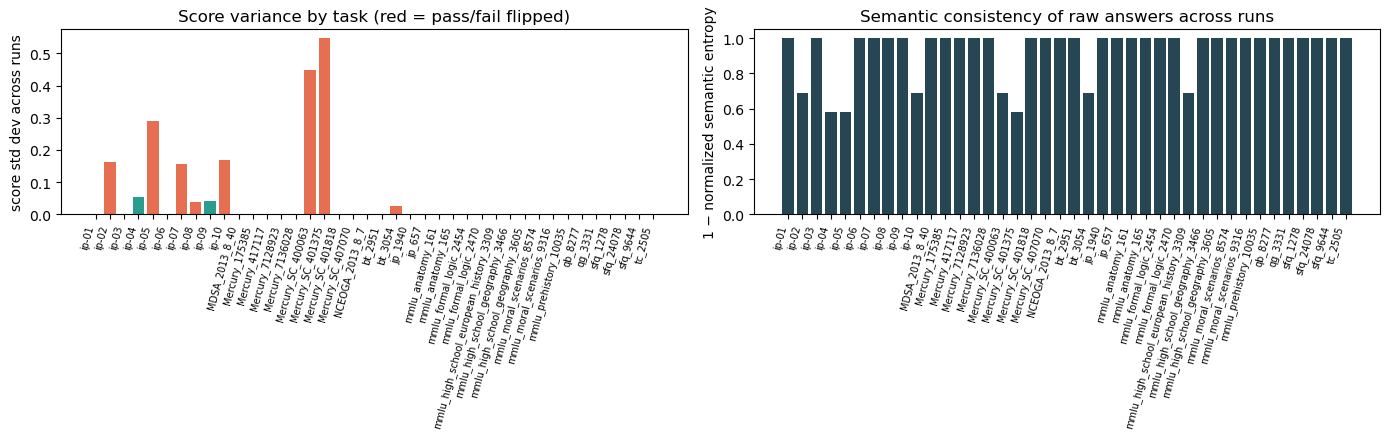

In [5]:
chatbot_chart = scenario.plot_chatbot_variance(chatbot_var)


## 🤖 Agentic Track

A fixed set of 5 Mind2Web web-navigation tasks, run 5× each in both single-agent (ReAct) and multi-agent (planner/navigator/validator) mode — 50 agent runs total. Each run is a full multi-step tool-calling loop, not a single completion, so this takes noticeably longer than the chatbot track.

**Methodology — what "consistent" means here, precisely, and why it's different from the chatbot track:** comparing raw agent trajectories as text would penalize an agent for using different-but-equivalent reasoning phrasing, which isn't the failure mode this scenario cares about. Instead:
1. **Task-outcome flip rate** — same idea as the chatbot track, applied to `task_passed`.
2. **Tool-selection variance** (`tool_f1` std dev across runs) — `tool_f1` is already equivalence-aware *upstream*, via `multi_agent_otel_eval`'s own flexible tool-equivalence mapping (calling a differently-named-but-functionally-equivalent tool isn't penalized as a wrong choice). High variance here would mean the agent's actions genuinely differed run to run — see the note below on what actually happened when this ran.

**What this section spends:** 50 agent runs (5 tasks × 5 repeats × 2 modes), each a multi-step tool-calling loop — roughly 15–20 minutes and real API spend across both the agent and judge calls the harness makes internally. There's no faster way to get real variance data here: fewer repeats would make the variance numbers less trustworthy, and this is already close to the minimum useful sample size.

The same Wilson-interval and BH-corrected significance layer from the chatbot track applies here too — with only 5 tasks per mode, the BH correction has very little power (5 simultaneous tests barely benefits from correcting for multiplicity), so treat `significant_below_floor` here as a much weaker signal than in the 40-task chatbot table, not as directly comparable.

In [6]:
harness = scenario.build_agent_harness(target_model)


In [7]:
agentic_runs = scenario.run_agentic_repeats(
    harness, n_tasks=scenario.AGENTIC_N_TASKS, n_repeats=scenario.AGENTIC_N_REPEATS
)
print(f"{len(agentic_runs['results'])} rows collected "
      f"({scenario.AGENTIC_N_REPEATS} repeats × {scenario.AGENTIC_N_TASKS} tasks × 2 modes)")


Using cached dataset: 300 tasks (/Users/minwu/Documents/GenAI/Agent/outputs/data/mind2web_train.jsonl)


50 rows collected (5 repeats × 5 tasks × 2 modes)


In [8]:
agentic_var = scenario.agentic_variance(agentic_runs["results"])
agentic_var.sort_values("task_score_std", ascending=False)


,task_id,mode,n_runs,avg_task_score,task_score_std,pass_rate,avg_tool_f1,tool_f1_std,avg_n_tool_calls,n_tool_calls_std,flips,website,pass_rate_ci_low,pass_rate_ci_high,reliability_p_value,significant_below_floor,reliability_category
9,4,single,5,0.778727,0.236348,0.8,0.400000,0.000000,48.8,21.004761,True,discogs,0.375528,0.963777,0.67232,False,reliable
2,1,multi,5,0.864000,0.087636,1.0,0.800000,0.000000,19.6,9.659193,False,ign,0.565509,1.000000,1.00000,False,reliable
1,0,single,5,0.795538,0.074699,0.8,0.285714,0.000000,32.6,17.558474,True,united,0.375528,0.963777,0.67232,False,reliable
4,2,multi,5,0.818000,0.063008,1.0,0.285714,0.000000,24.2,13.311649,False,discogs,0.565509,1.000000,1.00000,False,reliable
0,0,multi,5,0.832769,0.059564,1.0,0.264286,0.019562,50.4,23.922792,False,united,0.565509,1.000000,1.00000,False,reliable
5,2,single,5,0.798000,0.058481,1.0,0.285714,0.000000,18.0,7.035624,False,discogs,0.565509,1.000000,1.00000,False,reliable
6,3,multi,5,0.822000,0.051940,1.0,0.545455,0.000000,58.6,33.080206,False,discogs,0.565509,1.000000,1.00000,False,reliable
8,4,multi,5,0.880364,0.042023,1.0,0.500000,0.000000,48.6,27.281862,False,discogs,0.565509,1.000000,1.00000,False,reliable
3,1,single,5,0.884857,0.026833,1.0,0.666667,0.000000,14.6,7.436397,False,ign,0.565509,1.000000,1.00000,False,reliable
7,3,single,5,0.800000,0.000000,1.0,0.545455,0.000000,41.6,17.242390,False,discogs,0.565509,1.000000,1.00000,False,reliable


**A finding worth flagging before you read the chart below:** in every run of this scenario so far, `tool_f1_std` has come back essentially zero across every task and mode — even when `n_tool_calls` varies a lot. Read plainly, that means this framework's Tool Correctness score is driven by whether the required actions happened *at least once*, not by how much extra exploration or redundant tool-calling occurred around them. If you see the same pattern, `n_tool_calls_std` (in the table above) is carrying more of the actual behavioral-variance signal than `tool_f1_std` is — the report's Observations section checks for this automatically and adjusts which metric it leads with.

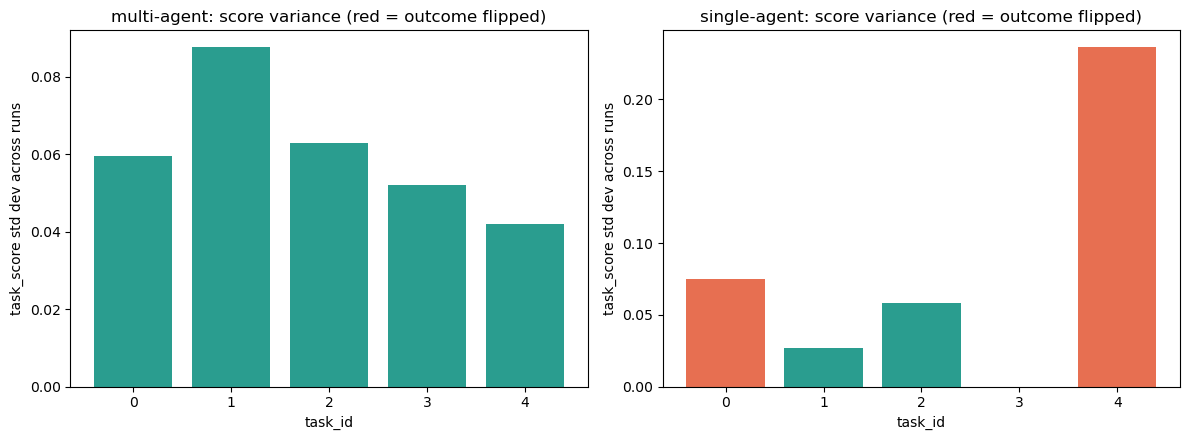

In [9]:
agentic_score_chart = scenario.plot_agentic_variance(agentic_var)


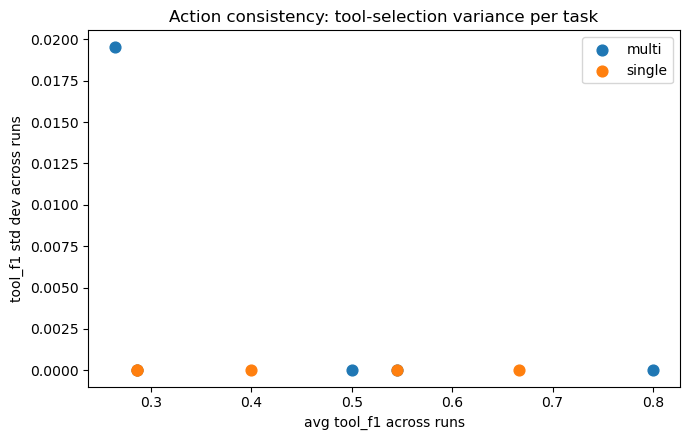

In [10]:
tool_chart = scenario.plot_tool_consistency(agentic_var)


<a id="reporting-template"></a>
## 📝 Testing Report

Built from this run's data through the same [uniform HTML template](../reporting/templates/scenario_report.html.j2) every scenario in this repo uses. The Observations section is generated programmatically from whatever this run's actual judge/variance output was — not hand-written — so it can't go stale the way a fixed paragraph would on a re-run with different numbers.

Report saved to outputs/reports/consistency_reliability.html



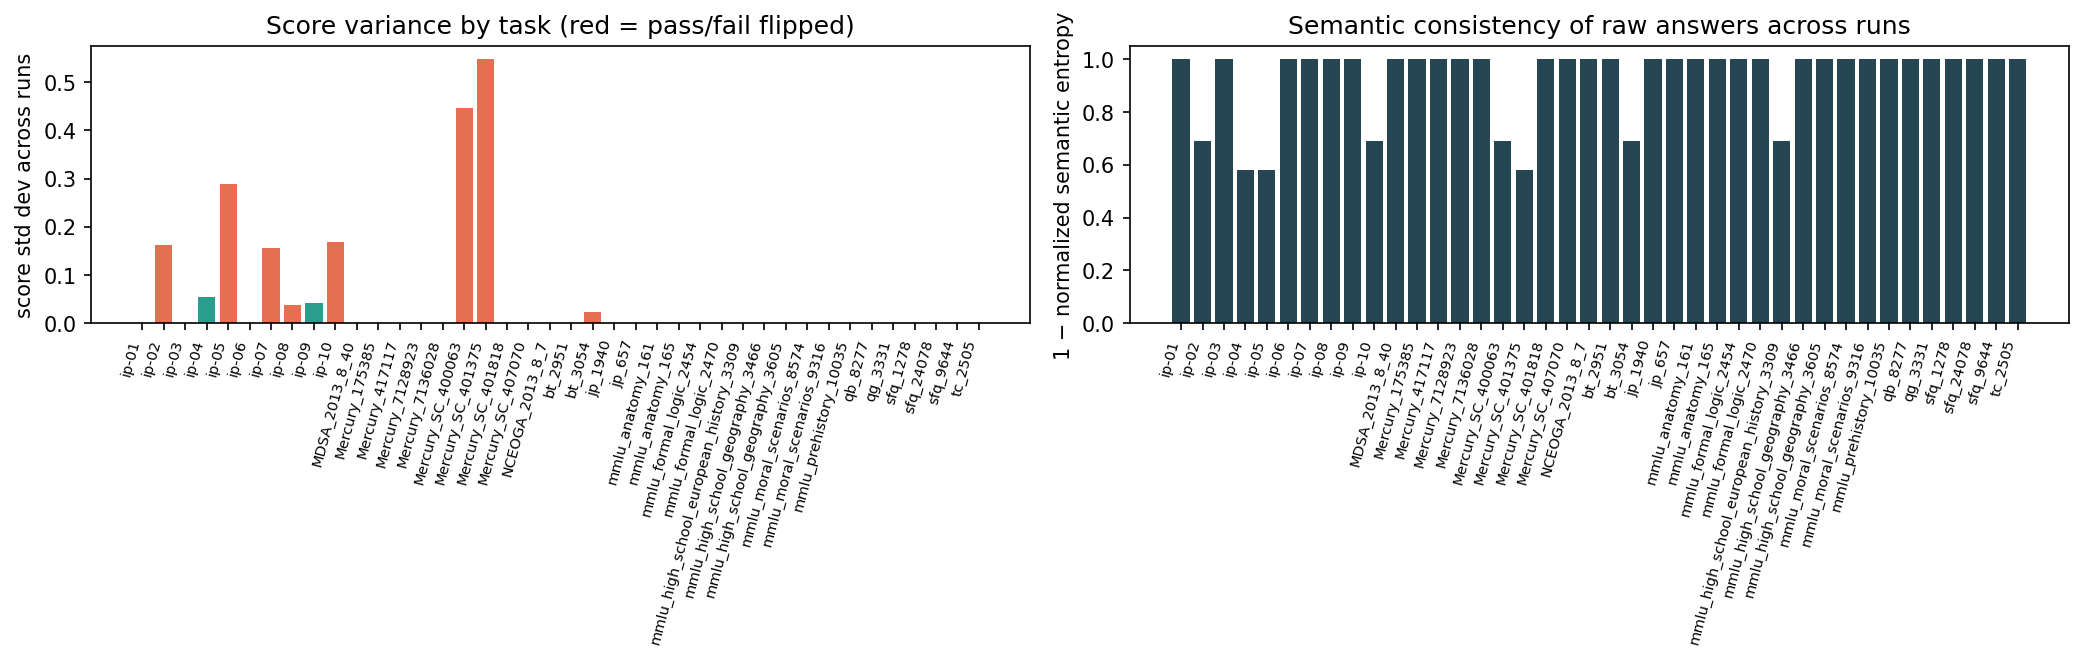
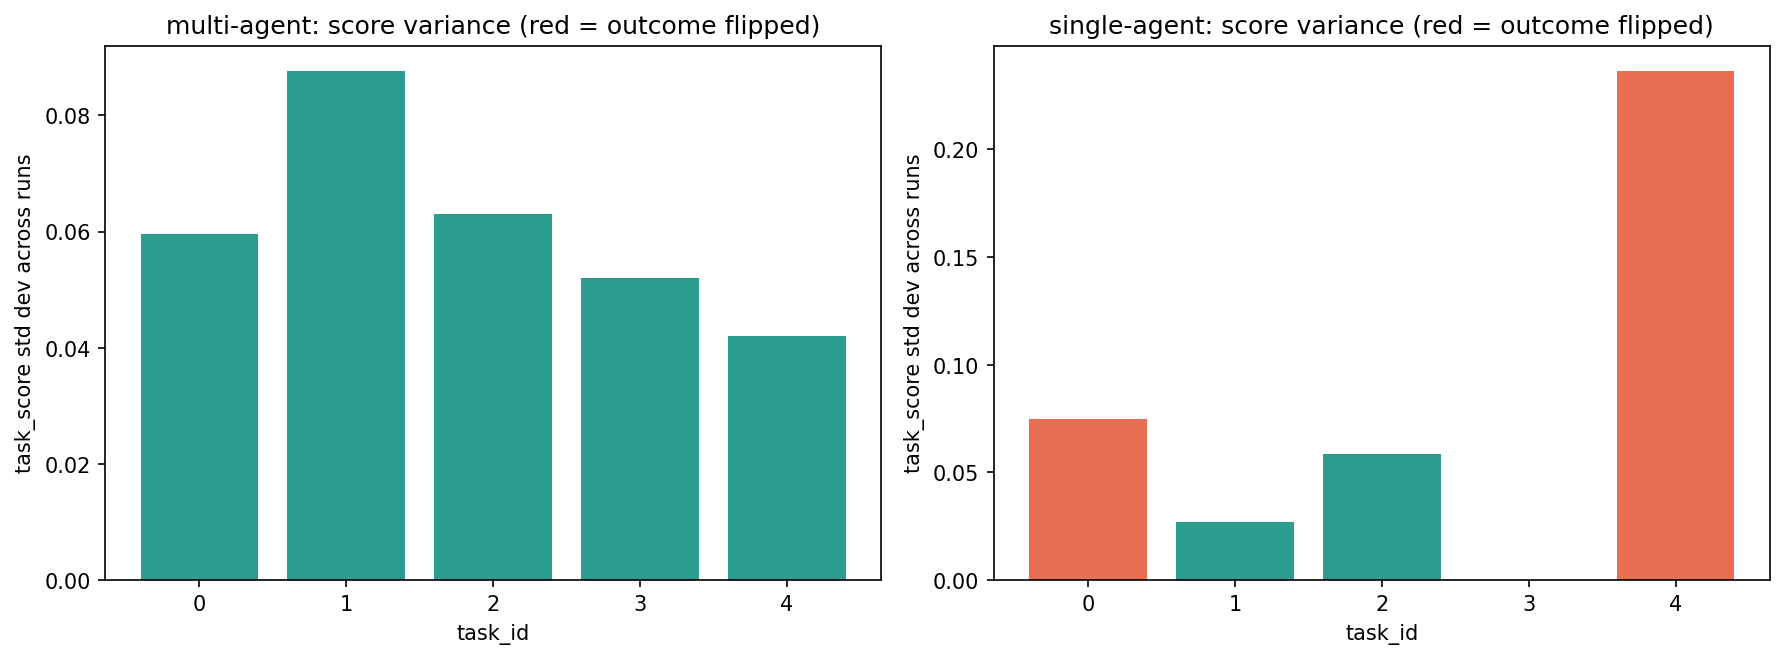
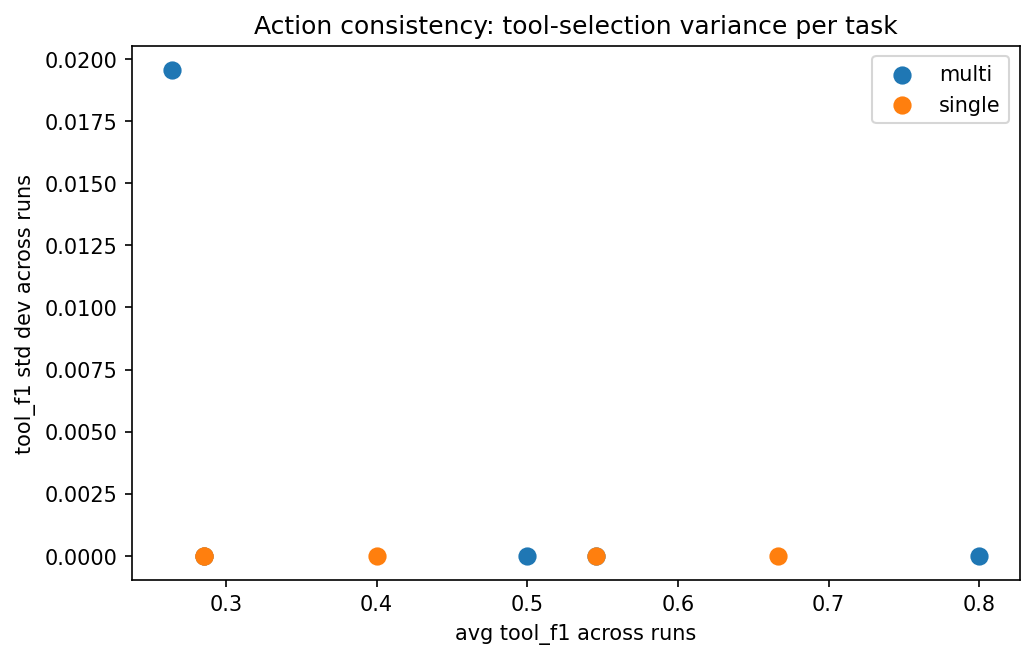

In [11]:
charts = [chatbot_chart, agentic_score_chart, tool_chart]
report = scenario.build_report(chatbot_var, agentic_var, target_model, api_version, charts)

html = render_report(report)
report_path = save_report(html, "outputs/reports/consistency_reliability.html")
print(f"Report saved to {report_path}")
embed_report(html)


## 🗂️ Documentation Trail

Every file this run read or produced, checked live (existence, size, last-modified) rather than just listed from memory. Unlike scenario 1, the raw per-repeat results here don't come free from the underlying adapter — `genai_capability_bench`'s `run_from_config` writes each repeat to the *same* fixed output directory, so without an explicit save step, only the last of 5 repeats would actually survive on disk even though the report's numbers reflect all 5. `save_artifacts()` below exists specifically to close that gap — the persisted CSVs, not just the notebook's in-memory results, are what a reviewer could actually check against this report's aggregated numbers.

In [12]:
saved_paths = scenario.save_artifacts(chatbot_runs["results"], chatbot_var, agentic_runs["results"], agentic_var)
artifact_trail(scenario.artifacts(saved_paths, report_path))


,artifact,path,status,size,last modified,description
0,Custom golden set (input),scenarios/fixtures/intended_performance.jsonl,present,6.6KB,2026-07-29 14:37:15,"Reused unchanged from scenario 1 — versioned, not regenerated per run."
1,Public benchmark sample (input),scenarios/fixtures/public_benchmark_sample.jsonl,present,54.1KB,2026-07-29 15:16:00,"Reused unchanged from scenario 1 — versioned, not regenerated per run."
2,Mind2Web task cache (input),../Agent/outputs/data/mind2web_train.jsonl,present,150.3KB,2026-06-02 00:23:21,"multi_agent_otel_eval's cached copy — outside this repo, in the sibling clone."
3,Chatbot raw results (all 5 repeats),outputs/runs/consistency_reliability/chatbot_raw_results.csv,present,329.4KB,2026-07-31 02:14:42,"Every individual run's per-task score, not just the aggregated variance — gitignored, regenerated every run."
4,Chatbot variance by task,outputs/runs/consistency_reliability/chatbot_variance.csv,present,6.4KB,2026-07-31 02:14:42,"The aggregated table shown above, as its own file."
5,Agentic raw results (all 5 repeats × 2 modes),outputs/runs/consistency_reliability/agentic_raw_results.csv,present,8.0KB,2026-07-31 02:14:42,"Every individual agent run's score, tool calls, and outcome — gitignored, regenerated every run."
6,Agentic variance by task and mode,outputs/runs/consistency_reliability/agentic_variance.csv,present,1.7KB,2026-07-31 02:14:42,"The aggregated table shown above, as its own file."
7,HTML testing report,outputs/reports/consistency_reliability.html,present,353.0KB,2026-07-31 02:14:42,"The rendered report embedded above — scope, data, results, charts, and observations."


<a id="how-to-extend"></a>
## 🔧 How to Extend This Scenario

- **Change the repeat count** — edit `scenario.CHATBOT_N_REPEATS` / `scenario.AGENTIC_N_REPEATS` in [`scenarios/consistency_reliability.py`](../scenarios/consistency_reliability.py). More repeats give more trustworthy variance numbers at proportionally more cost; 5 is a floor, not a target.
- **Test a different agentic task set** — `scenario.AGENTIC_N_TASKS` controls how many of the cached Mind2Web tasks get used; `AgentHarness.load_tasks(n)` always takes the first `n`, so the same tasks are reused run to run unless you change `n`.
- **Add a third track** (e.g. a RAG-backed assistant) — follow the same pattern as the agentic track: a new adapter in `adapters/`, a `run_*_repeats()` / `*_variance()` pair in this module reusing `reporting/repeat_run.py`'s `variance_by_task` with your own column names, and a new chart function.
- **Trade rigor for cost** — pass `use_semantic_entropy=False` to `scenario.chatbot_variance()` to use the free TF-IDF check (`reporting.repeat_run.add_pairwise_consistency`) instead of entailment clustering — same output columns, no client needed, faster for dev iteration. Not recommended as the default: see this notebook's own results for cases it would have missed.
- **Change what counts as "semantically consistent"** — `reporting.repeat_run.bidirectional_entailment` currently asks this repo's own target model to judge entailment; swapping in a dedicated NLI model (noted as a next step in the report) would be a change there, not in this notebook.
- **Change the reliability floor or significance level** — `scenario.MIN_ACCEPTABLE_PASS_RATE` (currently 0.80) and `add_reliability_significance`'s `alpha` (currently 0.05) are both stated policy choices, not derived from data — see [Methodology](#methodology-refinements) above.
- **Reuse the repeat-run harness for a different scenario** — `reporting/repeat_run.py`'s functions take column names as arguments specifically so they aren't tied to this scenario's data shape; drift detection ([`docs/drift_detection.md`](../docs/drift_detection.md)) is the next scenario expected to reuse them.